In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from deep_lambda_cox import DeepLambdaSA
from lambda_cox import LambdaSA
from baseline_cox import SA

from utils import concordance_index, unroll_time, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [6]:
config_path = '../configs/config_tasks.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [7]:
task_id = config['dataset_kwargs']['task_id']
task_id

11

In [8]:
aux = jnp.zeros(3)
isinstance(aux, jnp.ndarray)

True

In [9]:
#Baseline SA with and wo landmarking
num_exps = 5
sizes = [.2]

ibs_is = np.zeros((num_exps, len(sizes)))
ibs_lm = np.zeros((num_exps, len(sizes)))

ci_is = np.zeros((num_exps, len(sizes)))
ci_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_is[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        ci_is[fold, i] = concordance_index(scores, ts, cs)

        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        ci_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:24<00:00,  4.01it/s]



.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:27<00:00,  3.66it/s]



.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.89it/s]



.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.91it/s]



.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:26<00:00,  3.83it/s]

In [25]:
%%time

num_exps = 5
sizes = [.2]
size = sizes[0]
tgt_lrs = [.01]

bs_0 = np.zeros((num_exps, len(tgt_lrs)))
bs_1 = np.zeros((num_exps, len(tgt_lrs)))

ci_0 = np.zeros((num_exps, len(tgt_lrs)))
ci_1 = np.zeros((num_exps, len(tgt_lrs)))

for fold in range(num_exps):
    for i, tgt_lr in enumerate(tgt_lrs):
        config['target_lr'] = tgt_lr
        
        print(".", end="")
        
        # Landmarking.
        config['lambda_'] = .9
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_1[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        ci_1[fold, i] = concordance_index(scores, ts, cs)

        # TCSR.
        config['lambda_'] = 0.0
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.
.
.
.
.
CPU times: user 16min 19s, sys: 2min 16s, total: 18min 35s
Wall time: 7min 32s


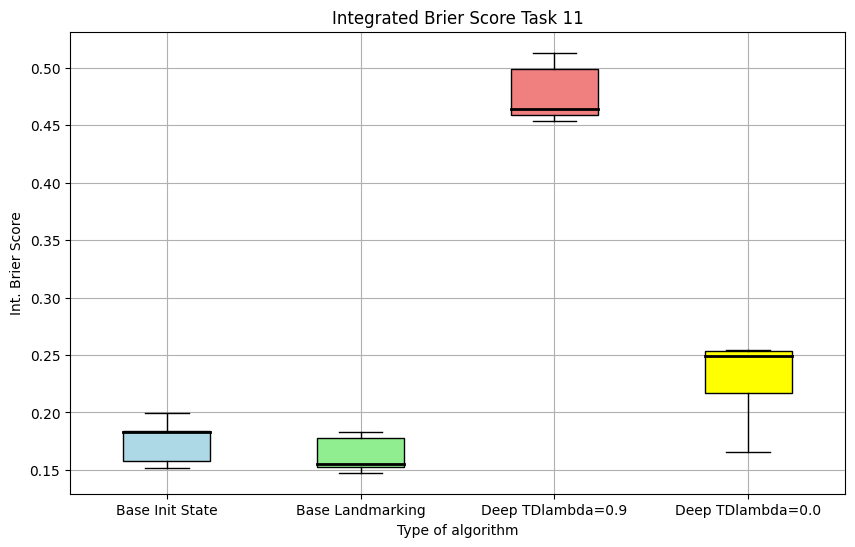

In [26]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
bs_is = ibs_is.reshape(-1)
bs_lm = ibs_lm.reshape(-1)
bs_a9 = bs_1.reshape(-1)
bs_a0 = bs_0.reshape(-1)
boxplot = ax.boxplot([bs_is, bs_lm, bs_a0, bs_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Base Init State', 'Base Landmarking', 'Deep TDlambda=0.9', 'Deep TDlambda=0.0'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
# plt.tight_layout()  # Ensures a tight layout
# plt.savefig("../../Figures/Int_brier_score_task_{}.pdf".format(task_id), format="pdf")

plt.show()


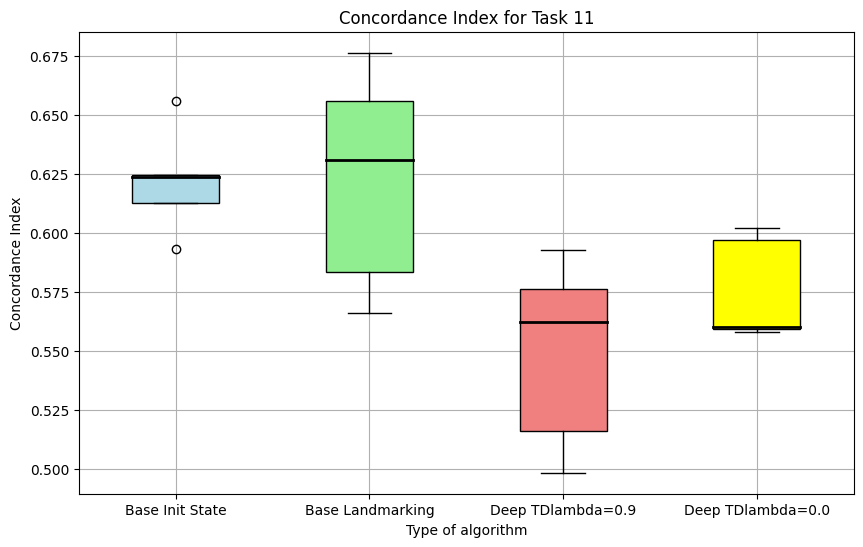

In [27]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
ci_is = ci_is.reshape(-1)
ci_lm = ci_lm.reshape(-1)
ci_a9 = ci_1.reshape(-1)
ci_a0 = ci_0.reshape(-1)
boxplot = ax.boxplot([ci_is, ci_lm, ci_a0, ci_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Base Init State', 'Base Landmarking', 'Deep TDlambda=0.9', 'Deep TDlambda=0.0'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Concordance Index")
ax.set_title("Concordance Index for Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
# plt.tight_layout()  # Ensures a tight layout
# plt.savefig("../../Figures/Int_brier_score_task_{}.pdf".format(task_id), format="pdf")

plt.show()


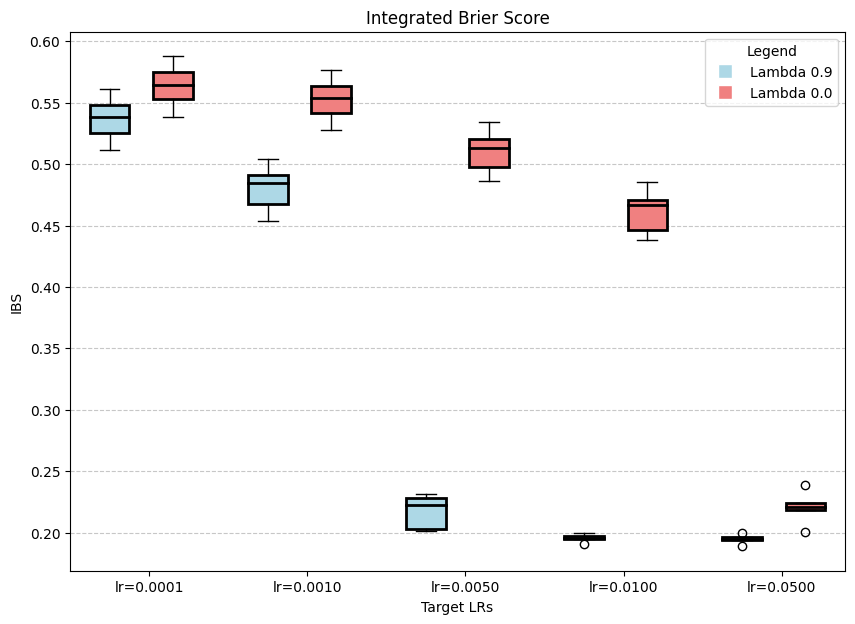

In [33]:
X = bs_1
Y = bs_0

# Create a list of positions for the boxplots
positions = np.arange(1, X.shape[1]*2, step=2)

# Set box colors
boxprops_X = dict(facecolor='lightblue', edgecolor='black', linewidth=2)
boxprops_Y = dict(facecolor='lightcoral', edgecolor='black', linewidth=2)

# Set mean line properties
medianprops = dict(color='black', linewidth=2)

# Set figure size
plt.figure(figsize=(10, 7))

# Plotting boxplots for X
plt.boxplot(X, positions=positions, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_X, medianprops=medianprops, patch_artist=True)

# Plotting boxplots for Y
plt.boxplot(Y, positions=positions + 0.8, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_Y, medianprops=medianprops, patch_artist=True)

# Create legend
legend_X = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightblue', markersize=10, label='Lambda 0.9')
legend_Y = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightcoral', markersize=10, label='Lambda 0.0')

plt.legend(handles=[legend_X, legend_Y], title='Legend')

# Customize the grid to have only horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set x-axis labels within boxplots
labels = [f'lr={lr:.4f}' for lr in tgt_lrs]
plt.xticks(positions+.5, labels, ha='center')


plt.xlabel('Target LRs')
plt.ylabel('IBS')
plt.title('Integrated Brier Score')

# Set y-axis limits
# plt.ylim(0.15, .25)

plt.show()


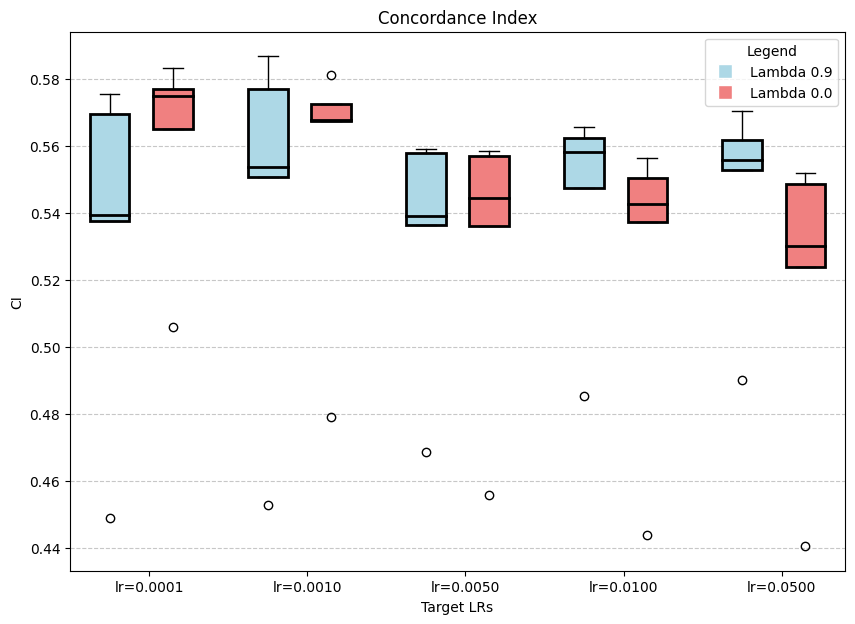

In [34]:
X = ci_1
Y = ci_0

# Create a list of positions for the boxplots
positions = np.arange(1, X.shape[1]*2, step=2)

# Set box colors
boxprops_X = dict(facecolor='lightblue', edgecolor='black', linewidth=2)
boxprops_Y = dict(facecolor='lightcoral', edgecolor='black', linewidth=2)

# Set mean line properties
medianprops = dict(color='black', linewidth=2)

# Set figure size
plt.figure(figsize=(10, 7))

# Plotting boxplots for X
plt.boxplot(X, positions=positions, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_X, medianprops=medianprops, patch_artist=True)

# Plotting boxplots for Y
plt.boxplot(Y, positions=positions + 0.8, labels=['' for i in range(len(tgt_lrs))], boxprops=boxprops_Y, medianprops=medianprops, patch_artist=True)

# Create legend
legend_X = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightblue', markersize=10, label='Lambda 0.9')
legend_Y = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightcoral', markersize=10, label='Lambda 0.0')

plt.legend(handles=[legend_X, legend_Y], title='Legend')

# Customize the grid to have only horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set x-axis labels within boxplots
labels = [f'lr={lr:.4f}' for lr in tgt_lrs]
plt.xticks(positions+.5, labels, ha='center')


plt.xlabel('Target LRs')
plt.ylabel('CI')
plt.title('Concordance Index')

# Set y-axis limits
# plt.ylim(0.6, 0.8)

plt.show()


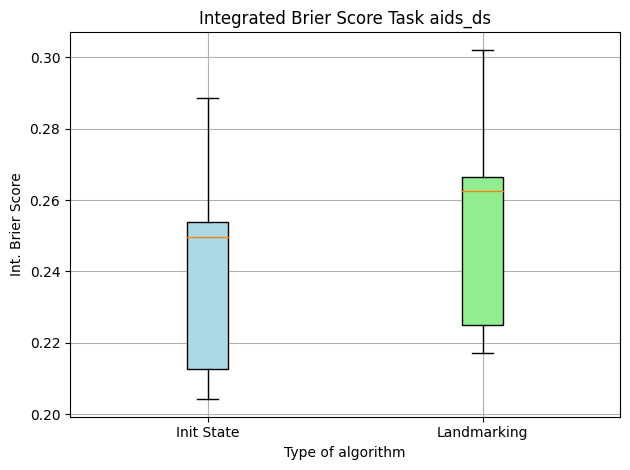

In [10]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res2_is.reshape(-1)
y = res2_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/Int_brier_score_task_{}.pdf".format(task_id), format="pdf")

plt.show()

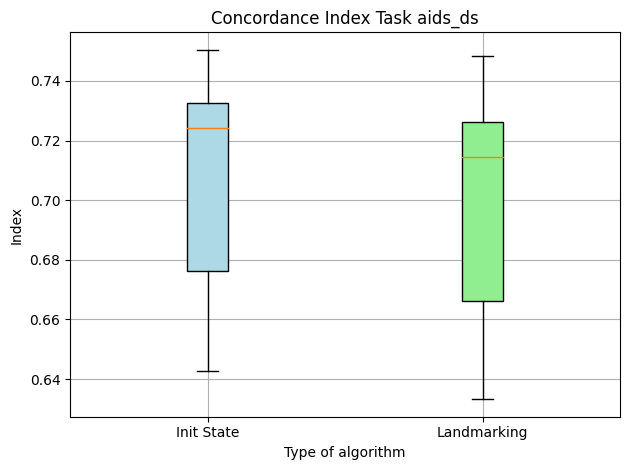

In [11]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res3_is.reshape(-1)
y = res3_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Index")
ax.set_title("Concordance Index Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/conc_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


In [113]:
config['target_lr'] = 0.01
config['num_epochs'] = 100
config['learning_rate'] = .01

In [30]:
config['lambda_'] = 0.0

In [31]:
config['num_epochs'] = 100

In [28]:
# train_gen, test_gen = model.get_train_test(test_size=.2)
# seqs = test_gen.X
# ts = test_gen.ts
# cs = test_gen.cs

model = DeepLambdaSA(config, seed=42)

In [29]:
losses = model.train(train_gen)

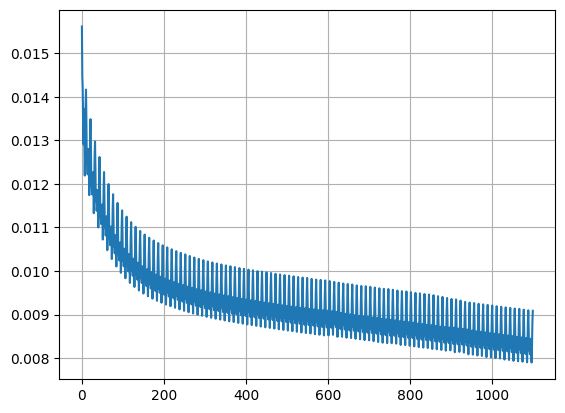

In [34]:
plt.plot(losses)
plt.grid()
plt.show()

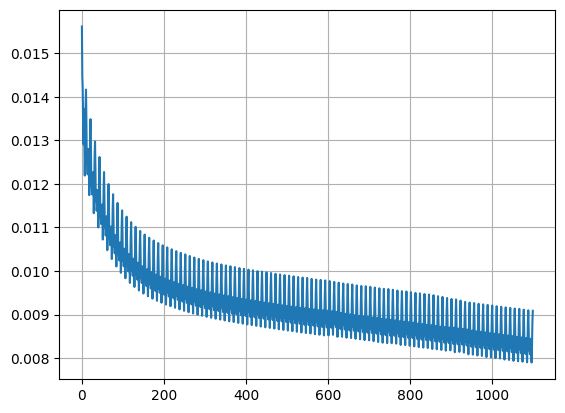

In [35]:
plt.plot(losses)
plt.grid()
plt.show()

In [121]:
len(losses)

1100

In [11]:
surv = model.survival_curve(seqs)
print('IBS ', model.integrated_brier_score(surv[:,0], ts, cs))

IBS  0.40668792


In [12]:
scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
print('CI: ', concordance_index(scores, ts, cs))

CI:  0.5


In [103]:
train_gen.X.shape

(324, 100, 39)